In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from autogluon.tabular import TabularPredictor

In [9]:
df = pd.read_csv('finaldata2.csv') 
print(df.head())

  currency address_city country_of_domicile birth_date nationality gender  \
0      DKK      Aalborg             Denmark    4/18/02      Danish      F   
1      EUR        Reims              France    5/31/74      French      M   
2      EUR  Montpellier              France   12/25/77      French      F   
3      EUR    Eindhoven         Netherlands    3/13/82       Dutch      F   
4      EUR        Siena               Italy    1/27/00     Italian      F   

  marital_status  higher_education investment_risk_profile investment_horizon  \
0         single                 1                    High             Medium   
1       divorced                 1            Considerable              Short   
2       divorced                 1                     Low              Short   
3        married                 1                Moderate             Medium   
4        married                 1                    High             Medium   

   ... aum_real_estate_value inheritance_details_r

In [5]:
!pip install autogluon

  Using cached autogluon-1.2-py3-none-any.whl.metadata (11 kB)
  Using cached autogluon.core-1.2-py3-none-any.whl.metadata (12 kB)
  Using cached autogluon.features-1.2-py3-none-any.whl.metadata (11 kB)
  Using cached autogluon.tabular-1.2-py3-none-any.whl.metadata (14 kB)
  Using cached autogluon.multimodal-1.2-py3-none-any.whl.metadata (12 kB)
  Using cached autogluon.timeseries-1.2-py3-none-any.whl.metadata (12 kB)
  Using cached autogluon.common-1.2-py3-none-any.whl.metadata (11 kB)
  Using cached hyperopt-0.2.7-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached accelerate-0.34.2-py3-none-any.whl.metadata (19 kB)
  Using cached jsonschema-4.21.1-py3-none-any.whl.metadata (7.8 kB)
  Using cached seqeval-1.2.2.tar.gz (43 kB)
  Preparing metadata (setup.py) ... done
  Using cached evaluate-0.4.3-py3-none-any.whl.metadata (9.2 kB)
  Using cached timm-1.0.3-py3-none-any.whl.metadata (43 kB)
  Using cached torchmetrics-1.2.1-py3-none-any.whl.metadata (20 kB)
  Using cached omegaconf-2

In [11]:
from sklearn.model_selection import train_test_split #splitting the dataset
from autogluon.tabular import TabularDataset, TabularPredictor #to handle tabular data and train models

In [12]:
# split into train and test sets
df_train,df_test=train_test_split(df,test_size=0.33,random_state=1)
df_train.shape,df_test.shape

((5266, 25), (2594, 25))

In [13]:
test_data=df_test.drop(['label'],axis=1)
test_data.head()

,currency,address_city,country_of_domicile,birth_date,nationality,gender,marital_status,higher_education,investment_risk_profile,investment_horizon,...,aum_inheritance,aum_real_estate_value,inheritance_details_relationship,inheritance_details_profession,inheritance_details_inheritance year,Family Background,Education Background,Wealth Summary,Client Summary,country
6201,EUR,Wavre,Belgium,2/3/02,Belgian,M,single,1,Considerable,Long-Term,...,2680000,0,grandfather,Neurosurgeon,2016.0,Smets Goossens De Smet is currently single. He...,Smets obtained his secondary school diploma fr...,He did not manage to save any money during his...,The RM is committed to helping Smets achieve f...,Belgium
3840,DKK,Århus N,Denmark,4/17/90,Danish,F,married,1,Considerable,Long-Term,...,31980000,5452000,grandmother,Venture Capitalist,2020.0,Olivia Gitte Hansen has been happily married t...,Olivia earned her secondary school diploma fro...,"While working, she saved 290000 DKK, which she...",The RM is very happy to have Olivia as a custo...,Denmark
3671,DKK,Frederiksberg,Denmark,10/16/73,Danish,F,single,1,Moderate,Short,...,34150000,2110000,father,Investment Banker,2010.0,Alma Freja Krog is currently single. She does ...,"In 1991, Alma graduated from Randers Statsskol...","While working, she saved 7860000 DKK, which sh...","Based on the information provided, we are exci...",Denmark
7565,DKK,Køge,Denmark,1/16/61,Danish,M,married,1,Moderate,Medium,...,0,5559000,NaN,NaN,NaN,Christensen Østergaard Jørgensen has been happ...,Christensen obtained his secondary school dipl...,"While working, he saved 6950000 DKK, which he ...","In light of the above, we are optimistic about...",Denmark
946,EUR,Maastricht,Netherlands,3/22/95,Dutch,M,single,1,Considerable,Medium,...,3510000,880000,grandmother,Hedge Fund Manager,2016.0,Brinkman Spaans De Jong is currently single. H...,Brinkman graduated from Gomarus College Gronin...,"Throughout his career, he saved 50000 EUR, inv...","Based on the information provided, we are exci...",Netherlands


In [ ]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(label='label').fit(
    train_data=df_train,
    time_limit=300,  #  limit to 5 minutes
    verbosity=2,
    presets='medium_quality'  # or 'fast_training' for even quicker results
)


In [17]:
predictor.fit_summary()

/opt/anaconda3/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


*** Summary of fit() ***
Estimated performance of each model:
                  model  score_val eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0              CatBoost   0.772296    accuracy       0.037467  9.824562                0.037467           9.824562            1       True          7
1   WeightedEnsemble_L2   0.772296    accuracy       0.037712  9.872757                0.000245           0.048195            2       True         14
2               XGBoost   0.730550    accuracy       0.015790  3.403349                0.015790           3.403349            1       True         11
3      RandomForestEntr   0.705882    accuracy       0.030256  1.926409                0.030256           1.926409            1       True          6
4      RandomForestGini   0.700190    accuracy       0.029565  1.920918                0.029565           1.920918            1       True          5
5       NeuralNetFastAI   0.669829    

{'model_types': {'KNeighborsUnif': 'KNNModel',
  'KNeighborsDist': 'KNNModel',
  'LightGBMXT': 'LGBModel',
  'LightGBM': 'LGBModel',
  'RandomForestGini': 'RFModel',
  'RandomForestEntr': 'RFModel',
  'CatBoost': 'CatBoostModel',
  'ExtraTreesGini': 'XTModel',
  'ExtraTreesEntr': 'XTModel',
  'NeuralNetFastAI': 'NNFastAiTabularModel',
  'XGBoost': 'XGBoostModel',
  'NeuralNetTorch': 'TabularNeuralNetTorchModel',
  'LightGBMLarge': 'LGBModel',
  'WeightedEnsemble_L2': 'WeightedEnsembleModel'},
 'model_performance': {'KNeighborsUnif': 0.5370018975332068,
  'KNeighborsDist': 0.5028462998102466,
  'LightGBMXT': 0.6698292220113852,
  'LightGBM': 0.6603415559772297,
  'RandomForestGini': 0.7001897533206831,
  'RandomForestEntr': 0.7058823529411765,
  'CatBoost': 0.7722960151802657,
  'ExtraTreesGini': 0.6660341555977229,
  'ExtraTreesEntr': 0.6698292220113852,
  'NeuralNetFastAI': 0.6698292220113852,
  'XGBoost': 0.7305502846299811,
  'NeuralNetTorch': 0.6489563567362429,
  'LightGBMLarge': 

In [18]:
predictor.leaderboard(df_train, silent=True)

/opt/anaconda3/lib/python3.12/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,RandomForestEntr,0.970566,0.705882,accuracy,0.130401,0.030256,1.926409,0.130401,0.030256,1.926409,1,True,6
1,RandomForestGini,0.969996,0.700190,accuracy,0.138721,0.029565,1.920918,0.138721,0.029565,1.920918,1,True,5
2,ExtraTreesEntr,0.966958,0.669829,accuracy,0.146048,0.029275,1.972456,0.146048,0.029275,1.972456,1,True,9
3,ExtraTreesGini,0.966578,0.666034,accuracy,0.138906,0.029406,2.076120,0.138906,0.029406,2.076120,1,True,8
4,NeuralNetTorch,0.912647,0.648956,accuracy,0.038490,0.009612,7.256498,0.038490,0.009612,7.256498,1,True,12
5,KNeighborsDist,0.900684,0.502846,accuracy,0.727735,0.108192,0.206411,0.727735,0.108192,0.206411,1,True,2
6,CatBoost,0.857957,0.772296,accuracy,0.065694,0.037467,9.824562,0.065694,0.037467,9.824562,1,True,7
7,WeightedEnsemble_L2,0.857957,0.772296,accuracy,0.067381,0.037712,9.872757,0.001687,0.000245,0.048195,2,True,14
8,XGBoost,0.825674,0.730550,accuracy,0.153780,0.015790,3.403349,0.153780,0.015790,3.403349,1,True,11
9,LightGBM,0.806684,0.660342,accuracy,0.056260,0.010871,2.516931,0.056260,0.010871,2.516931,1,True,4


In [19]:
y_pred = predictor.predict(test_data)
y_pred=pd.DataFrame(y_pred,columns=['label'])
y_pred 

,label
6201,1
3840,1
3671,1
7565,1
946,1
...,...
1042,1
1831,1
7142,1
3747,0


In [20]:
predictor.evaluate(df_test)

{'accuracy': 0.7386276021588281,
 'balanced_accuracy': 0.649128593038902,
 'mcc': 0.4222968864347832,
 'roc_auc': 0.6758998709717237,
 'f1': 0.8262429523321374,
 'precision': 0.7167630057803468,
 'recall': 0.9751966122202057}

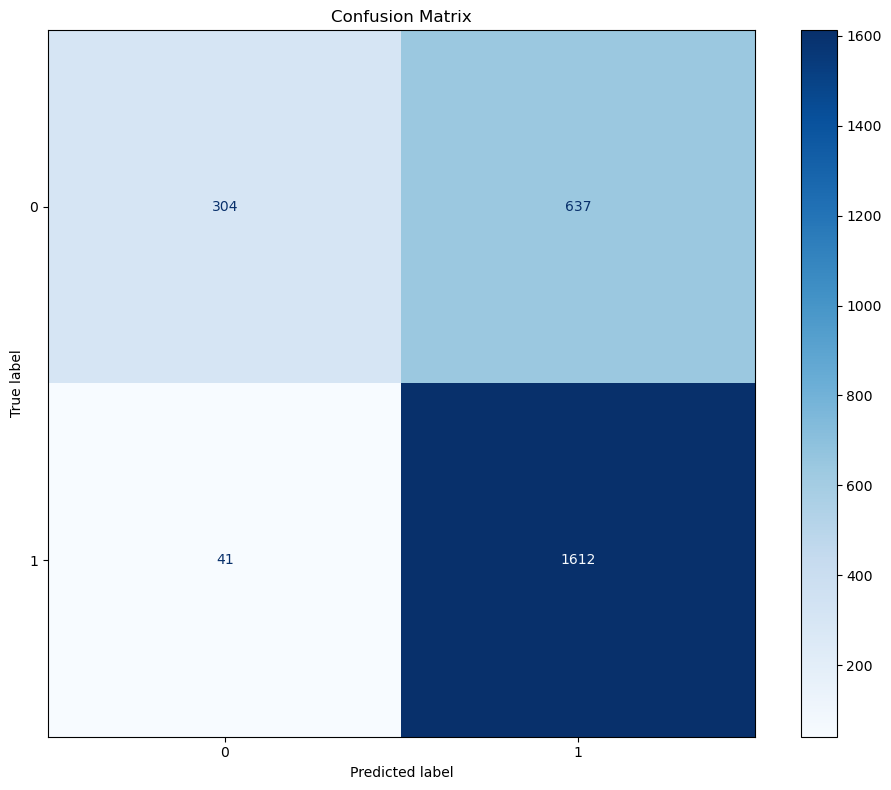

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.32      0.47       941
           1       0.72      0.98      0.83      1653

    accuracy                           0.74      2594
   macro avg       0.80      0.65      0.65      2594
weighted avg       0.78      0.74      0.70      2594



In [22]:
y_test = df_test['label']
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))